# 4. GridSearch & RandomSearch 하이퍼파라미터 튜닝

In [1]:
!pip install -q scikit-learn numpy matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import time

## 4-1. 가상 데이터셋 생성

In [3]:
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    n_classes=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (800, 20), Test: (200, 20)


## 4-2. GridSearchCV

In [4]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_search.fit(X_train, y_train)
grid_time = time.time() - start

print(f'Best Params : {grid_search.best_params_}')
print(f'Best CV Score: {grid_search.best_score_:.4f}')
print(f'Search Time  : {grid_time:.2f}s')

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Params : {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.9287
Search Time  : 2.00s


## 4-3. RandomizedSearchCV

In [5]:
param_dist = {
    'n_estimators': np.arange(50, 300, 10),
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': np.arange(2, 11)
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

start = time.time()
random_search.fit(X_train, y_train)
random_time = time.time() - start

print(f'Best Params : {random_search.best_params_}')
print(f'Best CV Score: {random_search.best_score_:.4f}')
print(f'Search Time  : {random_time:.2f}s')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params : {'n_estimators': np.int64(200), 'min_samples_split': np.int64(7), 'max_depth': None}
Best CV Score: 0.9313
Search Time  : 1.25s


## 4-4. 결과 비교

GridSearch   Test Accuracy: 0.9200  (time: 2.00s)
RandomSearch Test Accuracy: 0.9100  (time: 1.25s)


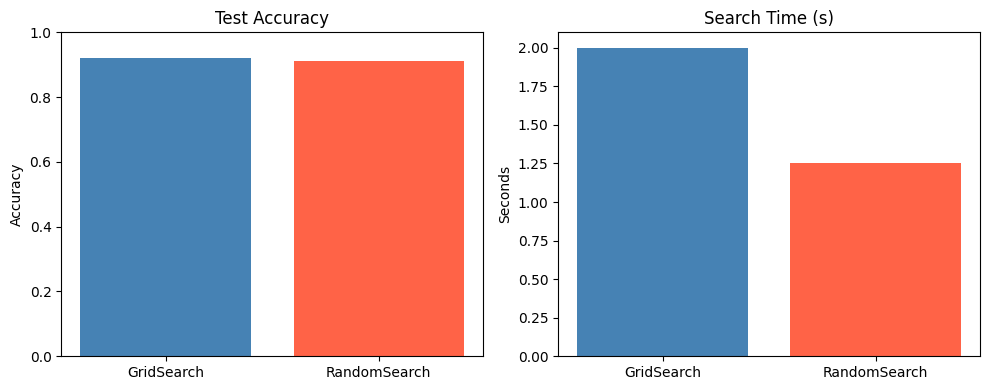

In [6]:
grid_acc   = accuracy_score(y_test, grid_search.best_estimator_.predict(X_test))
random_acc = accuracy_score(y_test, random_search.best_estimator_.predict(X_test))

print(f'GridSearch   Test Accuracy: {grid_acc:.4f}  (time: {grid_time:.2f}s)')
print(f'RandomSearch Test Accuracy: {random_acc:.4f}  (time: {random_time:.2f}s)')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['GridSearch', 'RandomSearch'], [grid_acc, random_acc], color=['steelblue', 'tomato'])
axes[0].set_title('Test Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)

axes[1].bar(['GridSearch', 'RandomSearch'], [grid_time, random_time], color=['steelblue', 'tomato'])
axes[1].set_title('Search Time (s)')
axes[1].set_ylabel('Seconds')

plt.tight_layout()
plt.show()